# Marketing Campaign
## Exploratory Data Analysis

Our project aims to predict customer response to targeted marketing campaigns for a retail food company. The next campaign will focus on a monthly food basket subscription service.
The main challenge lies in identifying which customers are most likely to respond positively to this offer, as untargeted marketing efforts result in low response rates and wasted resources.  
  
The goal of this exploratory data analysis is to:

- Understand the structure and quality of the dataset
- Identify potential data issues (missing values, outliers, imbalance)
- Explore customer characteristics and purchasing behavior
- Detect patterns associated with campaign response
- Extract insights that will guide feature engineering and model development

This analysis focuses on identifying predictive signals relevant to the target variable Response.

In [1]:
%cd ML_Group_AH

/content/ML_Group_AH


In [2]:
!ls data

marketing_campaign.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

df = pd.read_csv("data/marketing_campaign.csv", sep=";")

### 1. Dataset Overview
Before proceeding with deeper analysis, it is important to understand the basic structure of the dataset, including its size, variable types, and overall composition.  

This step helps identify potential preprocessing needs and provides context for subsequent analysis.

In [4]:
rows, cols = df.shape
print(f"The dataset has {rows} rows and {cols} columns.")
df.head()

The dataset has 2240 rows and 29 columns.


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


The dataset contains 2240 observations and 26 variables, including demographics,
purchase behavior and previous campaign responses.

Most variables are numerical, with a few categorical features such as `Education` and `Marital_Status`, and as we may notice `Dt_Customer` is stored as an object type. On this initial inspection it is possible to observe that some variables might contain missing values and outliers, which will be analysed in the data quality assesment stage.


### 2. Initial Target Variable Analysis
Before exploring the predictors, it is essential to analyze the target variable `Response`.

Understanding its distribution allows us to assess class imbalance and anticipate potential modeling challenges.

The target variable is naturally binary, as it indicates whether the customer accepted the latest marketing campaign offer. If Yes then `Response` = 1, if No then `Response` = 0.


Response distribution:
Response
0    1906
1     334
Name: count, dtype: int64 

Response
0    0.851
1    0.149
Name: proportion, dtype: float64


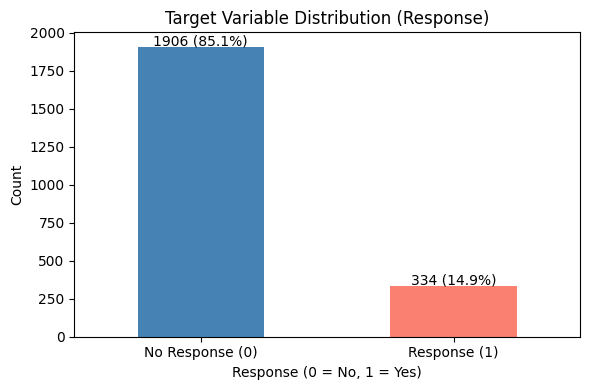

In [7]:
print("Response distribution:")
print(df['Response'].value_counts(), "\n")
print(df['Response'].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(6, 4))
df['Response'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], ax=ax)
ax.set_title('Target Variable Distribution (Response)')
ax.set_xlabel('Response (0 = No, 1 = Yes)')
ax.set_ylabel('Count')
ax.set_xticklabels(['No Response (0)', 'Response (1)'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width()/2, p.get_height()+10), ha='center')
plt.tight_layout()
plt.show()

Since only approximately 15% of customers responded to the campaign, we can conclude that the dataset shows a clear class imbalanced.

In cases where the classes are imbalanced, and many customers did not respond to campaign, accuracy can be misleading. The model will predict always 0, and as 85% of the customers did not answer, the model would stil acheive a high accuracy.
 Therefore,metrics like ROC-AUC and Precision will be futher use as evaluation metrics, as they better capture the model’s ability to correctly identify who are likely to respond to the campaign.  

 As a marketing prespective, well predicting which customers are likely to respond allows the company to target only interested customers, reduce marketing costs and increase  the campaign conversion rate.

### 3. Data Quality and Missing values
Assessing data quality is a critical step before model development.
In this section, we examine missing values, detect potential inconsistencies,
and evaluate whether corrective actions are required.

#### 3.1 Missing values overview

In [8]:
df.isnull().sum().sort_values(ascending=False)

,0
Income,24
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


Only the variable `Income` contains 24 missing observations, which represent a small proportion of the dataset.

Since the percentage is very low, removal is possible but imputation is preferable to preserve data, so median imputation will be applied during teh preprocessing stage.

#### 3.2 Data Types overview

In [9]:
df.dtypes

,0
ID,int64
Year_Birth,int64
Education,object
Marital_Status,object
Income,float64
Kidhome,int64
Teenhome,int64
Dt_Customer,object
Recency,int64
MntWines,int64


As mentioned before, `Dt_Customer` is stored as an object type although it represents the date when the customer register or created their account with the company. Thus, it will be converted to datetime format during preprocessing.

The variables `Education` and `Maritional_Status` are stored as object types, indicating categorical customer attributes.

Several variables represent binary indicators, such as previous campaign acceptance variables and the target variable that will be used for prediction : `Response`.

#### 3.3 Duplicates

In [10]:
df.duplicated().sum()
dup_lines = df.duplicated().sum()

if dup_lines == 0:
    print("The dataset does not contain duplicated lines.")
else:
    print(f"The dataset contains {dup_lines} duplicated lines.")

The dataset does not contain duplicated lines.


In [11]:
dup_ids = df['ID'].duplicated().sum()

if dup_ids == 0:
    print("The dataset does not contain duplicated IDs.")
else:
    print(f"The dataset contains {dup_ids} duplicated IDs.")

The dataset does not contain duplicated IDs.


Data consistency was verified by checking customer identifiers across the dataset, confirming that no duplicated IDs were found.

#### 3.4 Constant variables

In [12]:
df.nunique().sort_values(ascending=True)

,0
Z_Revenue,1
Z_CostContact,1
AcceptedCmp3,2
AcceptedCmp4,2
AcceptedCmp5,2
AcceptedCmp1,2
Complain,2
AcceptedCmp2,2
Response,2
Teenhome,3


The varaibles `Z_CostContact` and `Z_Revenue`, that represent the campaign economic analysis, to calculate the expected revenue or the cost per contact, are not customer features. Both appear to be constant among all observations, leading to conclude that they do not provide predictive modelling value.  

### 4. Data Preprocessing

Following the data quality assessment, preprocessing steps were applied to improve the dataset and prepare it for futher analysis and machine learning modelling. Here missing values, data types and some data inconsistencies will be handled.

#### 4.1 Handling Income Missing values

In [13]:
df['Income'].describe()

,Income
count,2216.000000
mean,52247.251354
std,25173.076661
min,1730.000000
25%,35303.000000
50%,51381.500000
75%,68522.000000
max,666666.000000


In [14]:
missing_pct = df['Income'].isnull().mean() * 100
print(f"The variable 'Income' contains {missing_pct:.2f}% missing values.")

The variable 'Income' contains 1.07% missing values.


In [15]:

df["Income_missing"] = df["Income"].isna()
df.groupby("Income_missing")[["Recency","NumWebPurchases","NumStorePurchases"]].mean()

,Recency,NumWebPurchases,NumStorePurchases
Income_missing,,,
False,49.012635,4.085289,5.800993
True,58.041667,4.041667,4.791667


Comparing customers with and without missing income values to assess whether the missingness could introduce bias, customers with missing income show slightly higher recency, indicating that they have purchased somewhat less recently. They also present marginally lower store purchases, while web purchases remain nearly identical between groups.  

However, these differences are relatively small and the number of missing observations is low (~1% of the dataset).
Given the low percentage of missing observations, no clear structural pattern or demographic concentration was identified.  

##### 4.1.1 Income distribution and Outliers

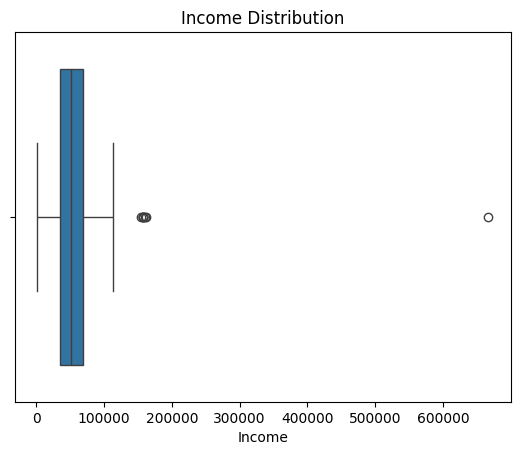

In [16]:
sns.boxplot(x=df["Income"])
plt.title("Income Distribution")
plt.show()

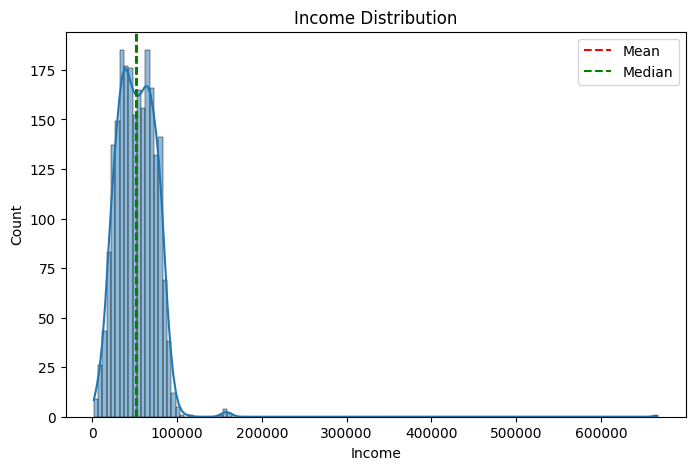

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df["Income"], kde=True)
plt.axvline(df["Income"].mean(), color="red", linestyle="--", label="Mean")
plt.axvline(df["Income"].median(), color="green", linestyle="--", label="Median")
plt.legend()
plt.title("Income Distribution")
plt.show()

The Income variable is right-skewed and contains an extreme outlier of approximately 666k. Since the mean is sensitive to extreme values, median imputation will be preferred to ensure robustness.

In [18]:
df['Income'] = df['Income'].fillna(df['Income'].median())

missing_pct = df['Income'].isnull().mean() * 100
print(f"The variable 'Income' contains {missing_pct:.2f}% missing values.")

The variable 'Income' contains 0.00% missing values.


#### 4.2 Data Type Conversion
The variable `Dt_Customer` was converted to a datetime format to enable time-based analusis and feature engineering.

In [19]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

print(f"The data type of 'Dt_Customer' is: {df['Dt_Customer'].dtype}")

The data type of 'Dt_Customer' is: datetime64[ns]


#### 4.3 Removing Useless Features
The variables `Z_CostContact` and `Z_Revenue` were identified as constant across all observations, meaning they contain only a single value throughout the dataset. Since variables without variability do not provide useful information for predictive modeling, they were removed from the dataset during the preprocessing stage.

In [20]:
df = df.drop(['Z_CostContact','Z_Revenue'], axis=1)
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'Income_missing'],
      dtype='object')

The variable ID represents a unique identifier assigned to each customer. Since identifier variables do not contain meaningful information about customer behavior and does not contribute to predicting the response variable, it was removed from the dataset before model training.
By removing this variable, we avoid the risk of the model learning artificial patterns or memorizing the data, called overfitting.

#### 4.4 Feature Engeneering

To improve the interpretability and usefulness of the dataset, new variables were derived from existing features.

##### 4.4.1 Customer Tenure
To capture customer loyalty and engagement, after converting the variable `Dt_Customer` to datetime format, a new variable `Customer_Tenure` was created.
This variable represents the number of days since the customer joined the company.

In [29]:
def create_customer_tenure(df):
    df = df.copy()
    df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
    df['Customer_Tenure'] = (df['Dt_Customer'].max() - df['Dt_Customer']).dt.days
    return df

df = create_customer_tenure(df)

##### 4.4.2 Age

The variable `Year_Birth` was transformed into a new feature called `Age`, calculated as the difference between the current year and the customer's birth year. This transformation improves interpretability and allows the model to use age as a meaningful demographic attribute.

In [30]:
def create_age(df):
    df = df.copy()
    current_year = pd.Timestamp.now().year
    df['Age'] = current_year - df['Year_Birth']
    df = df[df['Age'] < 100]
    return df

### 4. Feature Exploration
To improve predictive performance and capture meaningful behavioral patterns,
new features were created based on domain knowledge and business understanding.

These engineered variables aim to better represent customer value,
engagement level, and historical campaign responsiveness.

#### 4.1 Behavioral Aggregated Features

To better capture customer value and historical responsiveness,
two aggregated behavioral features were created:

- TotalSpend: represents overall customer expenditure across all product categories.
- PastCampaignAccepts: summarizes the number of previously accepted campaigns.

These features condense multiple related variables into more informative indicators,
reducing dimensionality while preserving predictive signal.

Customers with higher total spending and prior campaign acceptance
are expected to exhibit higher probability of responding to the new offer.

In [21]:
df["TotalSpend"] = df[
    ["MntWines","MntFruits","MntMeatProducts",
     "MntFishProducts","MntSweetProducts","MntGoldProds"]
].sum(axis=1)

df["PastCampaignAccepts"] = df[
    ["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3",
     "AcceptedCmp4","AcceptedCmp5"]
].sum(axis=1)

**Income vs Response**  
Income is analyzed to determine whether higher purchasing power
is associated with a greater likelihood of campaign acceptance.

Preliminary observations suggest that customers who responded
tend to have slightly higher income levels, indicating
that purchasing power may influence subscription decisions.

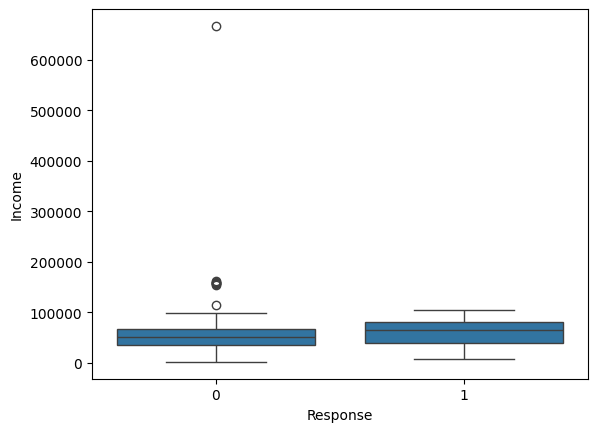

In [22]:
sns.boxplot(x="Response", y="Income", data=df)
plt.show()

**Recency vs Response**  
Recency measures the number of days since the customer's last purchase.

Customers with lower recency (more recent purchases)
appear more likely to respond to the campaign,
suggesting that recent engagement is an important behavioral signal.

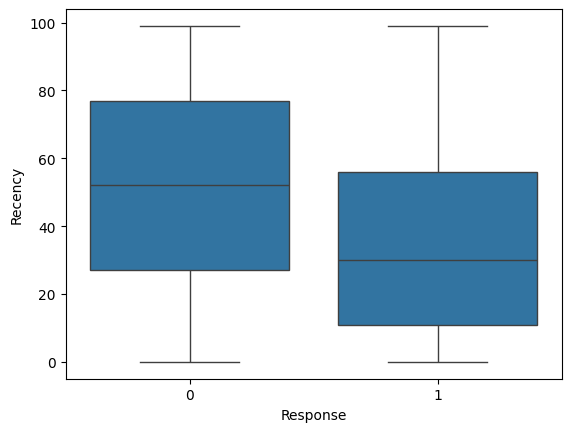

In [23]:
sns.boxplot(x="Response", y="Recency", data=df)
plt.show()

**Total Spend vs Response**  
Total Spend captures the overall monetary value
of purchases across all product categories.

Responders generally exhibit higher total spending,
indicating that high-value customers may be more receptive
to subscription-based offers.


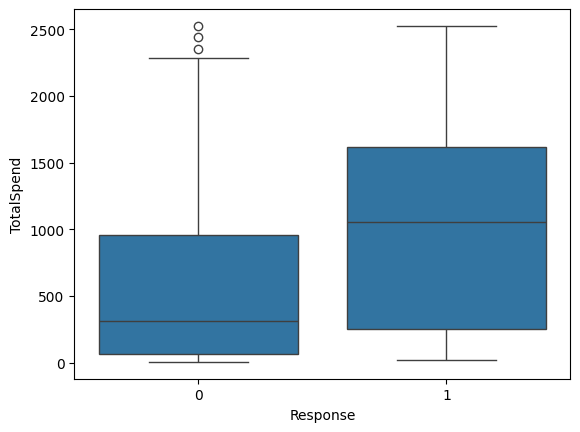

In [24]:
sns.boxplot(x="Response", y="TotalSpend", data=df)
plt.show()

**Past Campaing Accepts vs Response**  
Past Campaign Accepts summarizes historical campaign responsiveness.

A clear positive relationship is observed: customers who accepted
previous campaigns are significantly more likely to accept the new offer.

This variable is expected to be one of the strongest predictors
in the final machine learning model.

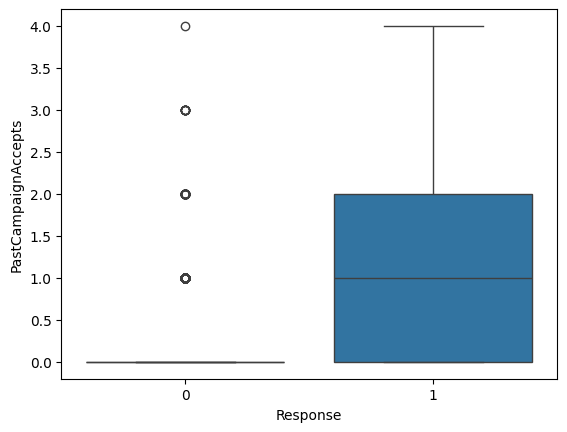

In [25]:
sns.boxplot(x="Response", y="PastCampaignAccepts", data=df)
plt.show()

### Key Predictive Patterns Identified

Campaign response is strongly associated with customer value and engagement. Responders tend to have higher income, higher total spending, and lower recency, indicating that recently active and high-value customers are more likely to accept the offer. Previous campaign acceptance emerges as one of the strongest behavioral predictors, suggesting consistency in responsiveness to marketing initiatives.

Income contains a small proportion of missing values (~1%), and no meaningful structural differences were observed between missing and non-missing customers. Therefore, median imputation will be applied during modeling without expected bias impact

## 6. Key Insights for Modeling

The exploratory analysis revealed several important patterns that will guide the modeling phase:

- The target variable is imbalanced (~15% positive responses), which suggests that evaluation metrics such as ROC-AUC, Precision-Recall AUC, and F1-score will be more appropriate than accuracy.

- Income contains a small proportion of missing values (~1%), and missingness appears approximately random. Median imputation will be applied within a modeling pipeline to prevent data leakage.

- The Income distribution is right-skewed and contains an extreme outlier. Tree-based models are expected to handle this robustly.

- Customers with lower Recency (more recent purchases) are more likely to respond, indicating that engagement recency is an important behavioral signal.

- Higher TotalSpend is associated with higher response probability, suggesting that high-value customers are more receptive to subscription offers.

- PastCampaignAccepts shows a strong positive relationship with Response and is expected to be one of the most predictive features.

Overall, behavioral and engagement-related variables appear more informative than purely demographic characteristics, reinforcing the importance of customer activity patterns in predicting campaign response.